<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Stacked Charts**


Estimated time needed: **45** minutes


In this lab, you will focus on visualizing data specifically using stacked charts. You will use SQL queries to extract the necessary data and apply stacked charts to analyze the composition and comparison within the data.


## Objectives


In this lab, you will perform the following:


- Visualize the composition of data using stacked charts.

- Compare multiple variables across different categories using stacked charts.

- Analyze trends within stacked chart visualizations.


## Setup: Downloading and Loading the Data
**Install the libraries**


In [ ]:
!pip install pandas

In [ ]:
!pip install matplotlib


**Download and Load the Data**


To start, download and load the dataset into a `pandas` DataFrame.



### Step 1: Download the dataset


In [ ]:
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

### Step 2: Import necessary libraries and load the dataset


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Load the data


In [2]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(url)

### Display the first few rows of the data to understand its structure


In [3]:
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Stacked Chart for Composition of Job Satisfaction Across Age Groups


##### 1. Stacked Chart of Median `JobSatPoints_6` and `JobSatPoints_7` for Different Age Groups


Visualize the composition of job satisfaction scores (`JobSatPoints_6` and `JobSatPoints_7`) across various age groups. This will help in understanding the breakdown of satisfaction levels across different demographics.



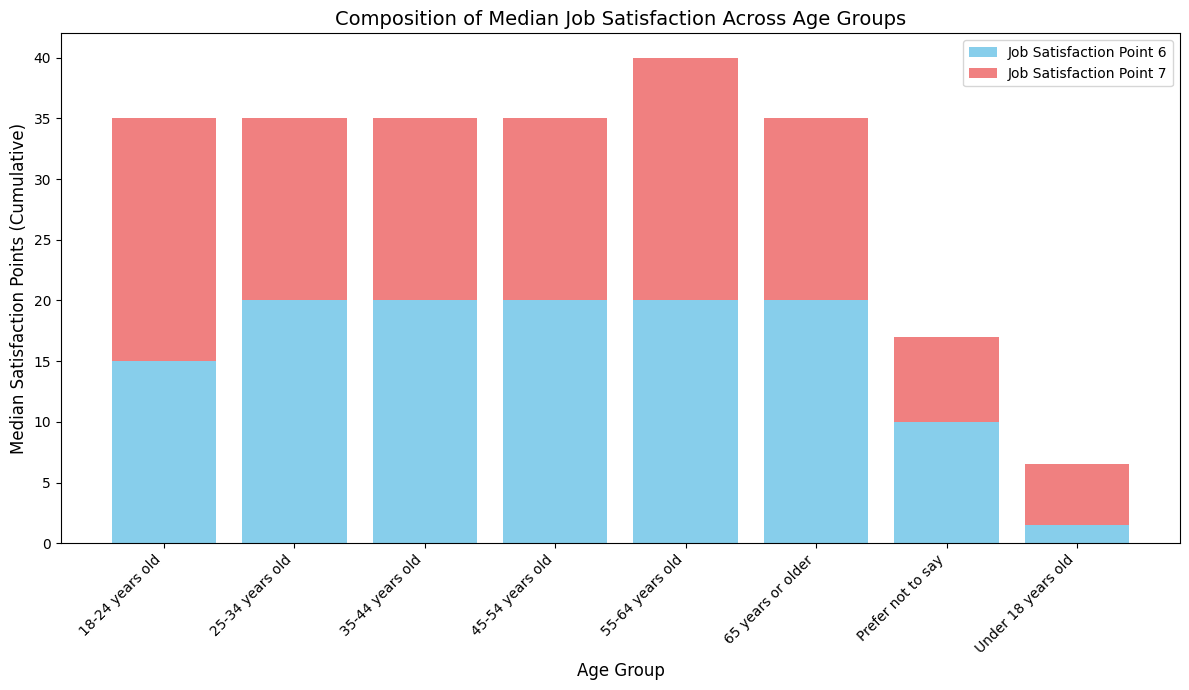

In [4]:
##Write your code here
# Convert satisfaction columns to numeric to ensure we can calculate the median
df['JobSatPoints_6'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')
df['JobSatPoints_7'] = pd.to_numeric(df['JobSatPoints_7'], errors='coerce')

# Group by Age and calculate the median for both satisfaction points
# drop rows with NaN values in these specific columns for a cleaner calculation
job_sat_age = df.groupby('Age')[['JobSatPoints_6', 'JobSatPoints_7']].median().reset_index()

plt.figure(figsize=(12, 7))

# first set of points
plt.bar(job_sat_age['Age'], job_sat_age['JobSatPoints_6'], label='Job Satisfaction Point 6', color='skyblue')

# second set of points on top of the first (using 'bottom' parameter)
plt.bar(job_sat_age['Age'], job_sat_age['JobSatPoints_7'], bottom=job_sat_age['JobSatPoints_6'], 
        label='Job Satisfaction Point 7', color='lightcoral')

plt.title('Composition of Median Job Satisfaction Across Age Groups', fontsize=14)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Median Satisfaction Points (Cumulative)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()

plt.show()

##### Stacked Chart of `JobSatPoints_6` and `JobSatPoints_7` for Employment Status


Create a stacked chart to compare job satisfaction (`JobSatPoints_6` and `JobSatPoints_7`) across different employment statuses. This will show how satisfaction varies by employment type.


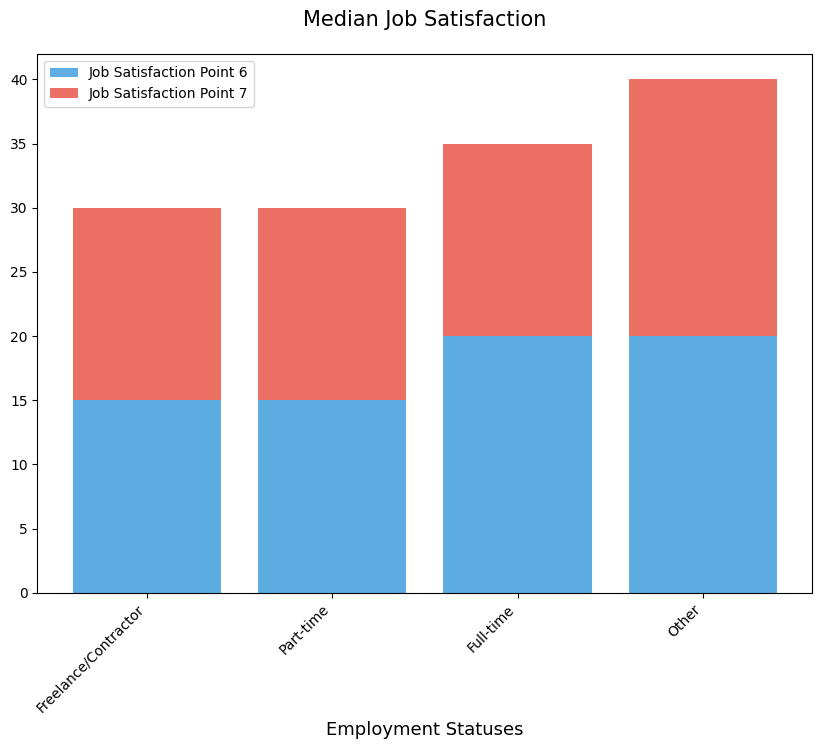

In [14]:
##Write your code here
df['JobSatPoints_6'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')
df['JobSatPoints_7'] = pd.to_numeric(df['JobSatPoints_7'], errors='coerce')

# simplify categories
def simplify_employment(text):
    if pd.isna(text):
        return "Unknown"
    elif "Independent contractor" in text:
        return "Freelance/Contractor"
    elif "Employed, full-time" in text:
        return "Full-time"
    elif "Employed, part-time" in text:
        return "Part-time"
    elif "Student" in text:
        return "Student"
    else:
        return "Other"

df['Employment_Simple'] = df['Employment'].apply(simplify_employment)

# Group and calculate median
emp_sat = df.groupby('Employment_Simple')[['JobSatPoints_6', 'JobSatPoints_7']].median()

# Drop "Student" from the data
emp_sat = emp_sat.drop('Student', errors='ignore')

# custom order (removing 'Student' from your list)
Employment_Simple_order = ['Freelance/Contractor', 'Part-time', 'Full-time', 'Other']
emp_sat = emp_sat.reindex(Employment_Simple_order)

plt.figure(figsize=(10, 7))

plt.bar(emp_sat.index, emp_sat['JobSatPoints_6'], label='Job Satisfaction Point 6', color='#5DADE2')
plt.bar(emp_sat.index, emp_sat['JobSatPoints_7'], bottom=emp_sat['JobSatPoints_6'], 
        label='Job Satisfaction Point 7', color='#EC7063')

plt.title('Median Job Satisfaction', fontsize=15, pad=20)
plt.xticks(rotation=45, ha='right') 
plt.xlabel('Employment Statuses', fontsize = 13)
plt.legend()
plt.show()

### Task 2: Stacked Chart for Compensation and Job Satisfaction by Age Group


##### This stacked chart visualizes the composition of compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) specifically for respondents aged 30-35.


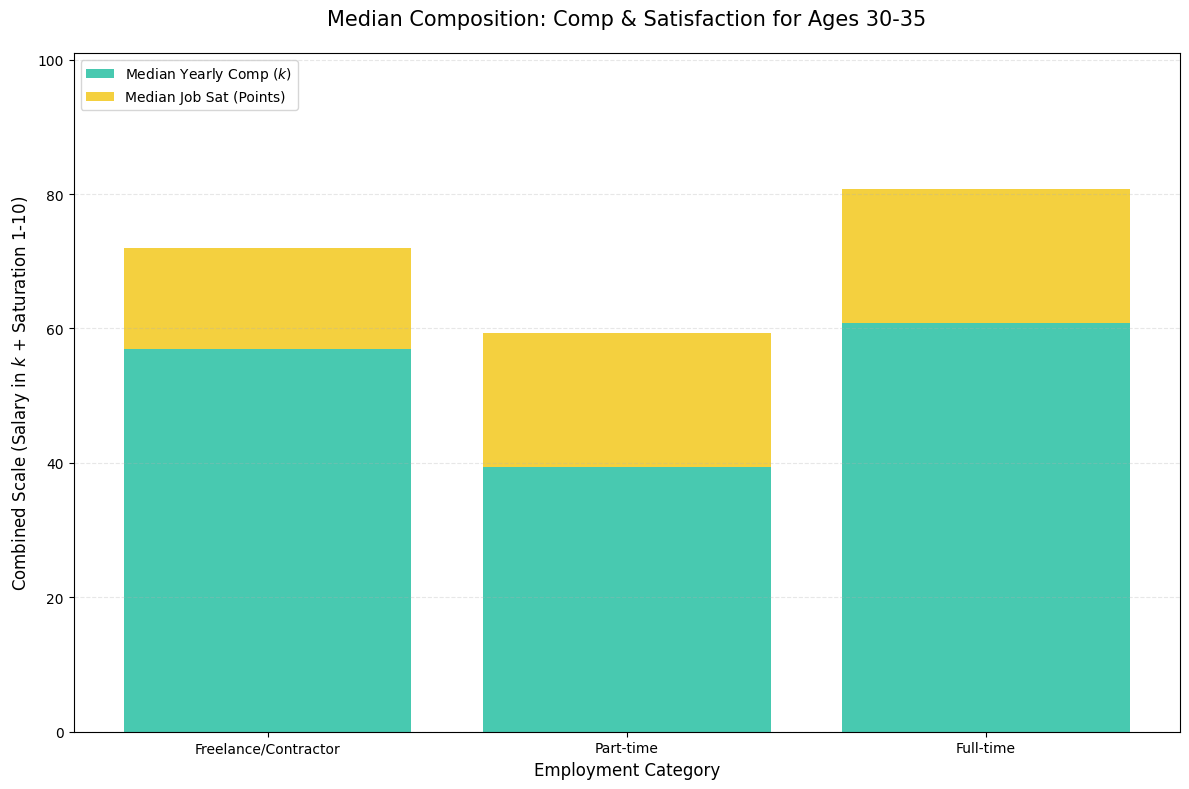

In [23]:
##Write your code here
# Note: Stack Overflow data usually uses '35-44 years old' or '25-34 years old'
# I filter for the 25-34 bracket, which covers most of the 30-35 requirement
age_group_df = df[df['Age'] == '25-34 years old'].copy()

# 2Clean and Convert columns
age_group_df['Comp_k'] = pd.to_numeric(age_group_df['ConvertedCompYearly'], errors='coerce') / 1000
age_group_df['JobSatPoints_6'] = pd.to_numeric(age_group_df['JobSatPoints_6'], errors='coerce')

# Apply your simplification function and drop 'Student'
age_group_df['Employment_Simple'] = age_group_df['Employment'].apply(simplify_employment)
age_group_df = age_group_df[age_group_df['Employment_Simple'] != 'Student']

# Group by Category and calculate Medians
consolidated_data = age_group_df.groupby('Employment_Simple')[['Comp_k', 'JobSatPoints_6']].median()

# 5. Specific order
Employment_Simple_order = ['Freelance/Contractor', 'Part-time', 'Full-time', 'Other']
consolidated_data = consolidated_data.reindex(Employment_Simple_order)

plt.figure(figsize=(12, 8))

# Bottom segment: Compensation
plt.bar(consolidated_data.index, consolidated_data['Comp_k'], 
        label='Median Yearly Comp ($k$)', color='#48C9B0')

# Top segment: Satisfaction
plt.bar(consolidated_data.index, consolidated_data['JobSatPoints_6'], 
        bottom=consolidated_data['Comp_k'], 
        label='Median Job Sat (Points)', color='#F4D03F')

max_val = (consolidated_data['Comp_k'] + consolidated_data['JobSatPoints_6']).max()
plt.ylim(0, max_val * 1.25) 

plt.title('Median Composition: Comp & Satisfaction for Ages 30-35', fontsize=15, pad=20)
plt.ylabel('Combined Scale (Salary in $k$ + Saturation 1-10)', fontsize=12)
plt.xlabel('Employment Category', fontsize=12)
plt.legend(loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()

##### Stacked Chart of Median Compensation and Job Satisfaction Across Age Group


Compare the median compensation and job satisfaction metrics across different age groups. This helps visualize how compensation and satisfaction levels differ by age.


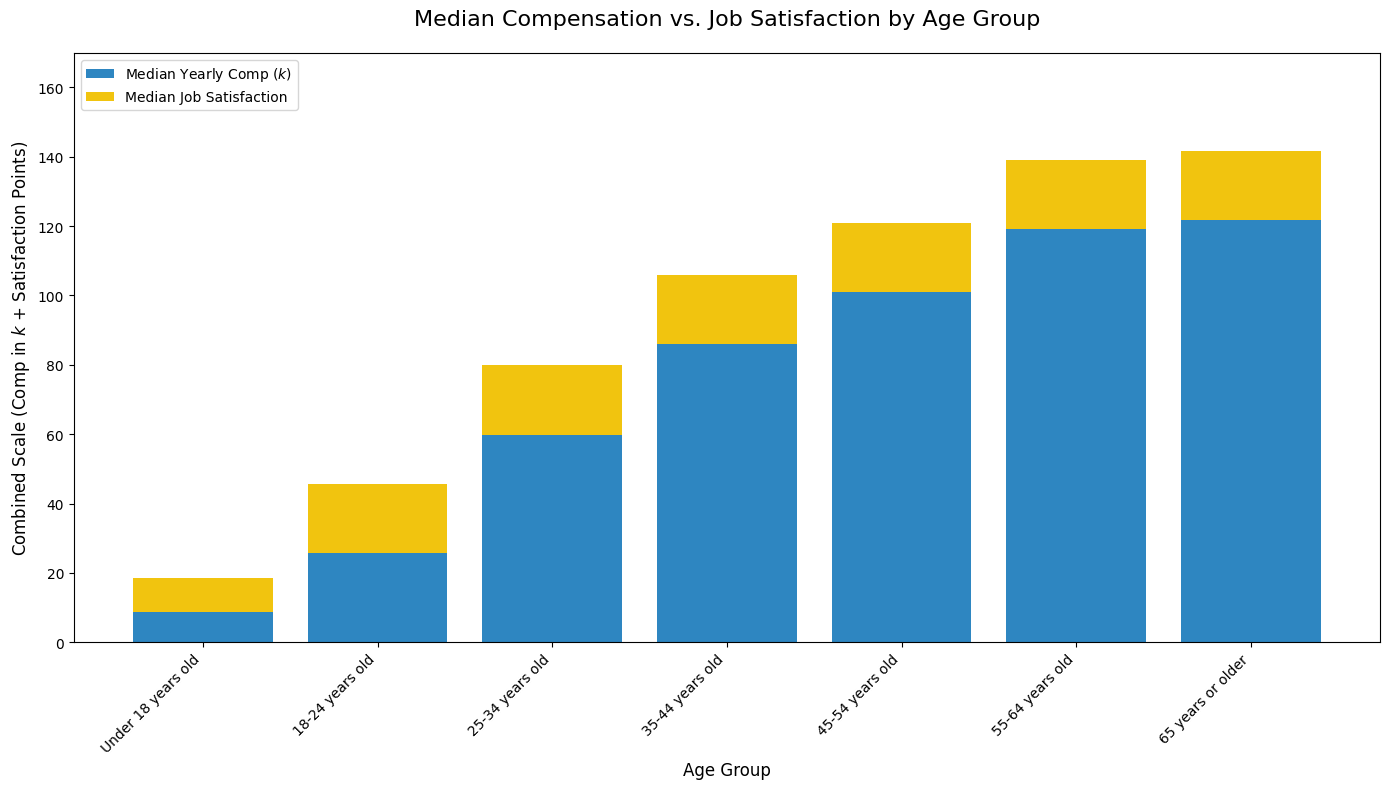

In [25]:
##Write your code here
df['Comp_k'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce') / 1000
df['JobSatPoints_6'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')

# Group by Age and calculate Medians
# .dropna() to ensure only calculate for rows with valid data
age_composition = df.dropna(subset=['Comp_k', 'JobSatPoints_6']).groupby('Age')[['Comp_k', 'JobSatPoints_6']].median()

age_order = ['Under 18 years old', '18-24 years old', '25-34 years old', 
             '35-44 years old', '45-54 years old', '55-64 years old', '65 years or older']
age_composition = age_composition.reindex(age_order).dropna()

plt.figure(figsize=(14, 8))

# Bottom segment: Median Compensation
plt.bar(age_composition.index, age_composition['Comp_k'], 
        label='Median Yearly Comp ($k$)', color='#2E86C1')

# Top segment: Median Satisfaction
plt.bar(age_composition.index, age_composition['JobSatPoints_6'], 
        bottom=age_composition['Comp_k'], 
        label='Median Job Satisfaction', color='#F1C40F')

# Formatting for Clarity
max_height = (age_composition['Comp_k'] + age_composition['JobSatPoints_6']).max()
plt.ylim(0, max_height * 1.2) 

plt.title('Median Compensation vs. Job Satisfaction by Age Group', fontsize=16, pad=20)
plt.ylabel('Combined Scale (Comp in $k$ + Satisfaction Points)', fontsize=12)
plt.xlabel('Age Group', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(loc='upper left')
plt.tight_layout()

plt.show()

### Task 3: Comparing Data Using Stacked Charts


##### 1. Stacked Chart of Preferred Databases by Age Group




Visualize the top databases that respondents from different age groups wish to learn. Create a stacked chart to show the proportion of each database in each age group.


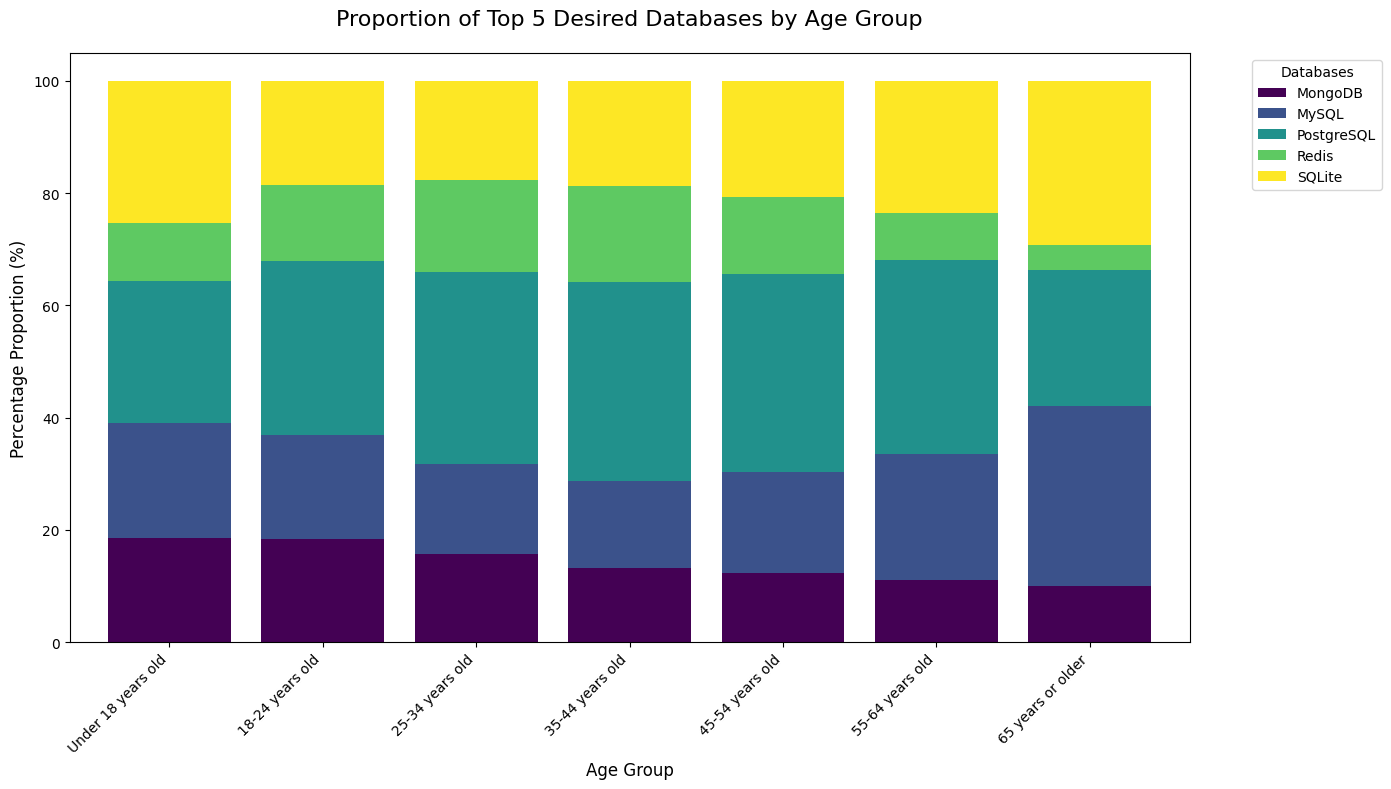

In [26]:
##Write your code here
top_db_list = df['DatabaseWantToWorkWith'].str.split(';').explode().value_counts().head(5).index.tolist()

db_age_df = df[['Age', 'DatabaseWantToWorkWith']].dropna()
db_age_df['DatabaseWantToWorkWith'] = db_age_df['DatabaseWantToWorkWith'].str.split(';')
db_age_df = db_age_df.explode('DatabaseWantToWorkWith')
db_age_df = db_age_df[db_age_df['DatabaseWantToWorkWith'].isin(top_db_list)]

db_counts = pd.crosstab(db_age_df['Age'], db_age_df['DatabaseWantToWorkWith'])

db_proportions = db_counts.div(db_counts.sum(1), axis=0) * 100

age_order = ['Under 18 years old', '18-24 years old', '25-34 years old', 
             '35-44 years old', '45-54 years old', '55-64 years old', '65 years or older']
db_proportions = db_proportions.reindex(age_order).dropna()

db_proportions.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='viridis', width=0.8)

plt.title('Proportion of Top 5 Desired Databases by Age Group', fontsize=16, pad=20)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Percentage Proportion (%)', fontsize=12)
plt.legend(title='Databases', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

##### 2. Stacked Chart of Employment Type by Job Satisfaction


Analyze the distribution of employment types within each job satisfaction level using a stacked chart. This will provide insights into how employment types are distributed across various satisfaction ratings.


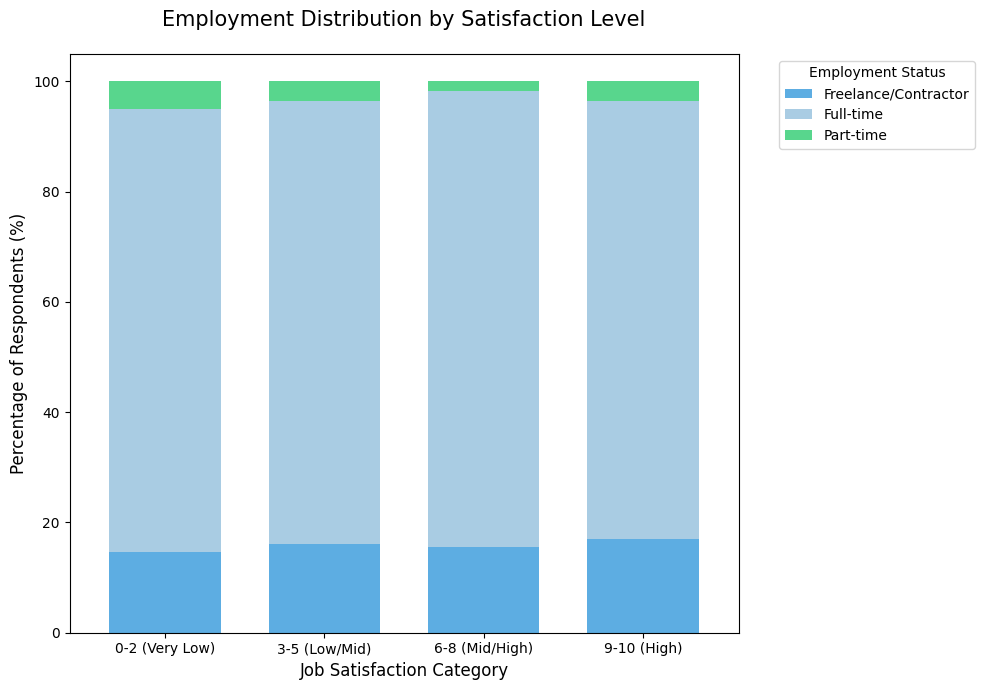

In [32]:
##Write your code here
df['JobSatPoints_6'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')

# scores grouped into 4 clear levels
bins = [0, 3, 6, 8, 11] # Covers 0-2, 3-5, 6-8, and 9-10
labels = ['0-2 (Very Low)', '3-5 (Low/Mid)', '6-8 (Mid/High)', '9-10 (High)']
df['Sat_Category'] = pd.cut(df['JobSatPoints_6'], bins=bins, labels=labels, right=False)

# Clean up Employment categories
def simplify_employment(text):
    if pd.isna(text): return "Unknown"
    if "Independent contractor" in text: return "Freelance/Contractor"
    if "Employed, full-time" in text: return "Full-time"
    if "Employed, part-time" in text: return "Part-time"
    return "Other"

df['Employment_Simple'] = df['Employment'].apply(simplify_employment)

# Remove Students and rows with no satisfaction data
df_clean = df[(df['Employment_Simple'] != 'Student') & (df['Sat_Category'].notna())]

# Create Normalized Cross-tabulation (percentage of each employment type within each Satisfaction Category)
dist_data = pd.crosstab(df_clean['Sat_Category'], df_clean['Employment_Simple'])
dist_pct = dist_data.div(dist_data.sum(1), axis=0) * 100

ax = dist_pct.plot(kind='bar', stacked=True, figsize=(10, 7), 
                   color=['#5DADE2', '#A9CCE3', '#58D68D', '#ABB2B9'], width=0.7)

plt.title('Employment Distribution by Satisfaction Level', fontsize=15, pad=20)
plt.xlabel('Job Satisfaction Category', fontsize=12)
plt.ylabel('Percentage of Respondents (%)', fontsize=12)
plt.legend(title='Employment Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0) # Keeps labels horizontal and easy to read
plt.tight_layout()

plt.show()

### Task 4: Exploring Technology Preferences Using Stacked Charts


##### 1. Stacked Chart for Preferred Programming Languages by Age Group


Analyze how programming language preferences (`LanguageAdmired`) vary across age groups.


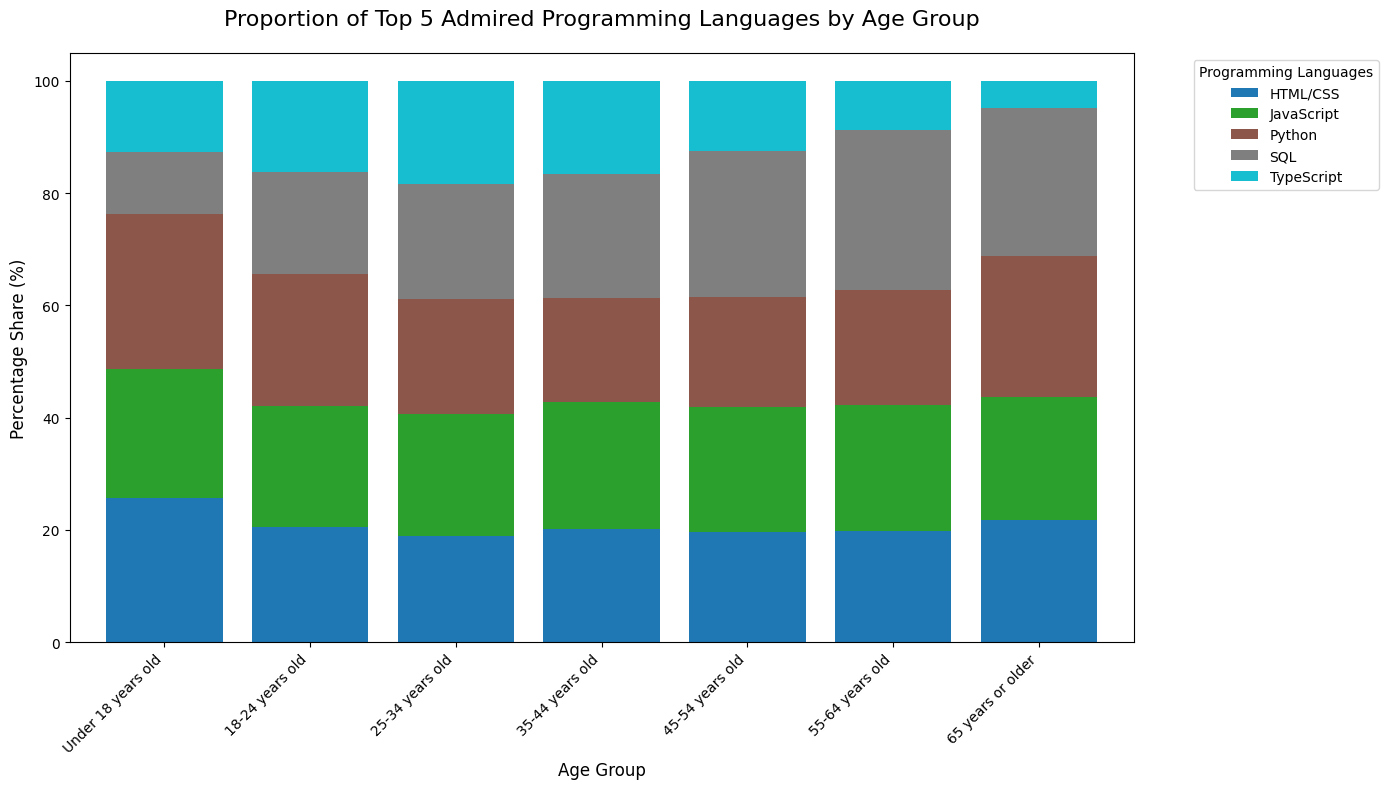

In [34]:
##Write your code here
df_lang = df[['Age', 'LanguageAdmired']].dropna()
df_lang['LanguageAdmired'] = df_lang['LanguageAdmired'].str.split(';')

df_lang = df_lang.explode('LanguageAdmired')

top_5_langs = df_lang['LanguageAdmired'].value_counts().head(5).index.tolist()

df_lang_filtered = df_lang[df_lang['LanguageAdmired'].isin(top_5_langs)]

lang_counts = pd.crosstab(df_lang_filtered['Age'], df_lang_filtered['LanguageAdmired'])

# Normalize to 100% (Proportions)
lang_proportions = lang_counts.div(lang_counts.sum(1), axis=0) * 100

age_order = ['Under 18 years old', '18-24 years old', '25-34 years old', 
             '35-44 years old', '45-54 years old', '55-64 years old', '65 years or older']
# Reindex and drop any categories that might not have data
lang_proportions = lang_proportions.reindex(age_order).dropna()

ax = lang_proportions.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='tab10', width=0.8)

plt.title('Proportion of Top 5 Admired Programming Languages by Age Group', fontsize=16, pad=20)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Percentage Share (%)', fontsize=12)
plt.legend(title='Programming Languages', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

##### 2. Stacked Chart for Technology Adoption by Employment Type


Explore how admired platforms (`PlatformAdmired`) differ across employment types (e.g., full-time, freelance)


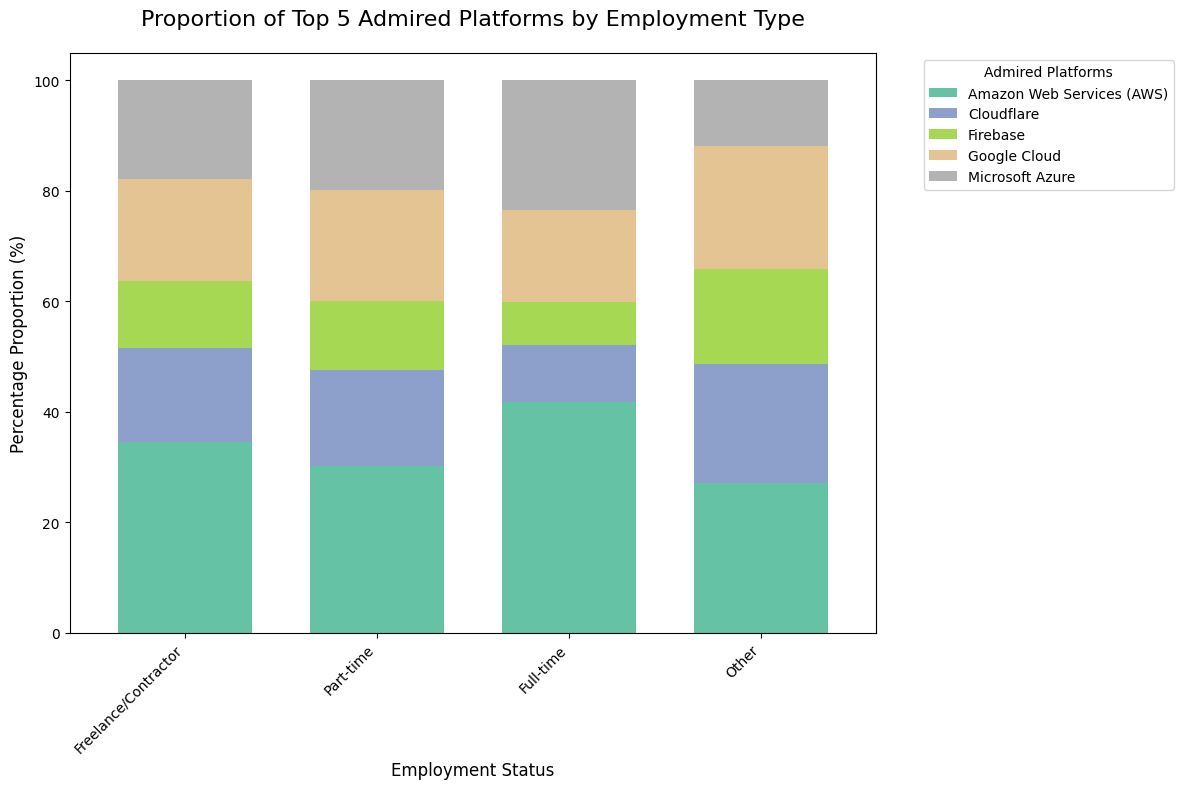

In [35]:
##Write your code here
def simplify_employment(text):
    if pd.isna(text): return "Unknown"
    if "Independent contractor" in text: return "Freelance/Contractor"
    if "Employed, full-time" in text: return "Full-time"
    if "Employed, part-time" in text: return "Part-time"
    return "Other"

df_plat = df[['Employment', 'PlatformAdmired']].dropna()
df_plat['Employment_Simple'] = df_plat['Employment'].apply(simplify_employment)

df_plat['PlatformAdmired'] = df_plat['PlatformAdmired'].str.split(';')
df_plat = df_plat.explode('PlatformAdmired')

top_5_platforms = df_plat['PlatformAdmired'].value_counts().head(5).index.tolist()
df_plat_filtered = df_plat[df_plat['PlatformAdmired'].isin(top_5_platforms)]

plat_counts = pd.crosstab(df_plat_filtered['Employment_Simple'], df_plat_filtered['PlatformAdmired'])
plat_proportions = plat_counts.div(plat_counts.sum(1), axis=0) * 100

Employment_Simple_order = ['Freelance/Contractor', 'Part-time', 'Full-time', 'Other']
plat_proportions = plat_proportions.reindex(Employment_Simple_order).dropna()

ax = plat_proportions.plot(kind='bar', stacked=True, figsize=(12, 8), colormap='Set2', width=0.7)

plt.title('Proportion of Top 5 Admired Platforms by Employment Type', fontsize=16, pad=20)
plt.xlabel('Employment Status', fontsize=12)
plt.ylabel('Percentage Proportion (%)', fontsize=12)
plt.legend(title='Admired Platforms', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

### Final Step: Review


In this lab, you focused on using stacked charts to understand the composition and comparison within the dataset. Stacked charts provided insights into job satisfaction, compensation, and preferred databases across age groups and employment types.


## Summary


After completing this lab, you will be able to:

- Use stacked charts to analyze the composition of data across categories, such as job satisfaction and compensation by age group.

- Compare data across different dimensions using stacked charts, enhancing your ability to communicate complex relationships in the data.

- Visualize distributions across multiple categories, such as employment type by satisfaction, to gain a deeper understanding of patterns within the dataset.


## Author:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
